# Hybrid Quantum Image Classification with PennyLane + PyTorch
## Ovarian cancer histopathology dataset (Kaggle)

This notebook pivots from the earlier **VQE/TSP** experiment to a **supervised hybrid quantum-classical image classifier**.

We will build the pipeline in small, testable steps:

1. Understand the task and choose a practical learning setup.
2. Download and index the Kaggle histopathology dataset.
3. Create train/validation/test splits.
4. Train a **classical baseline** (ResNet18 transfer learning).
5. Build a **hybrid CNN + QNN** model with:
   - a small quantum layer,
   - **data re-uploading**,
   - extra classical **non-linearity** before and after the quantum block,
   - configurable gradient method (`adjoint` or `parameter-shift`).
6. Compare the baseline and hybrid models.
7. Inspect results with confusion matrices and class-wise metrics.

---

## Why a hybrid model instead of a fully quantum image classifier?

Histopathology images are large, high-dimensional inputs. Encoding whole images directly into a quantum circuit is not practical on today's simulators or hardware.

A more realistic design is:

**Image → classical CNN backbone → compact feature vector → QNN layer → classifier head**

This lets the CNN do the heavy visual feature extraction, while the QNN acts as a small trainable nonlinear representation block.

---

## What changes compared with VQE?

VQE solves an optimization problem by minimizing the expectation value of a Hamiltonian for one instance.  
Here we move to **supervised learning**:

- we have labeled images,
- we minimize a classification loss (cross-entropy),
- we evaluate generalization on validation/test sets.

So this notebook is **machine learning**, unlike the earlier TSP/VQE notebook.

## Optional installs

Your `pyproject.toml` already includes `pennylane`, `pennylane-lightning`, `pennylane-lightning-gpu`, `torch`, `numpy`, `pandas`, and `matplotlib`.

For this image-classification notebook, we also want:

- `torchvision` for image transforms and pretrained CNNs,
- `scikit-learn` for stratified splits and metrics,
- `Pillow` for image loading,
- `tqdm` for progress bars,
- `kaggle` if you want to download from the Kaggle CLI inside the notebook.

Run the next cell if you need any of these.

In [ ]:
# Uncomment if your environment still misses some of these packages.
# %pip install -q torchvision scikit-learn pillow tqdm kaggle

## Imports

In [1]:
import os
import random
import zipfile
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

import pennylane as qml

print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)

/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Torch: 2.10.0+cu128
PennyLane: 0.44.0


In [6]:
os.chdir("..")
os.getcwd()

'/home/vinvs/projects/quantum/bio-quantum'

## Reproducibility and global configuration

A quantum-classical training loop can be noisy even on simulators, especially if you later enable finite shots or parameter-shift.

We start with a **deterministic-ish** setup:

- fixed random seeds,
- stable split sizes,
- explicit config block for the experiment.

The configuration is deliberately small at first so you can run a **smoke test** before scaling up.

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

@dataclass
class Config:
    # Paths
    dataset_root: str = "./data/interim/ovarian_histopathology"
    zip_path: str = "./data/raw/ovarian-cancer-and-subtypes-dataset-histopathology.zip"

    # Task
    task_mode: str = "binary"        # "binary" or "multiclass"
    positive_class_keyword: str = "non"  # used to detect non-cancer class in binary mode

    # Splits
    val_size: float = 0.15
    test_size: float = 0.15

    # Images
    image_size: int = 224

    # Loader
    batch_size: int = 16
    num_workers: int = 2
    pin_memory: bool = True

    # Baseline training
    baseline_epochs: int = 3

    # Hybrid training
    hybrid_epochs: int = 3
    freeze_backbone: bool = True

    # Quantum block
    n_qubits: int = 4
    n_reuploads: int = 3
    q_depth_per_block: int = 1
    q_grad_method: str = "adjoint"   # "adjoint" or "parameter-shift"
    q_shots: Optional[int] = None    # None for analytic expectations, or e.g. 256 for sampling
    q_device_preference: str = "auto" # "auto", "lightning.gpu", "lightning.qubit", "default.qubit"

    # Debug / smoke test
    max_images_per_class: Optional[int] = 300
    quick_run: bool = True

cfg = Config()
cfg

Config(dataset_root='./data/interim/ovarian_histopathology', zip_path='./data/raw/ovarian-cancer-and-subtypes-dataset-histopathology.zip', task_mode='binary', positive_class_keyword='non', val_size=0.15, test_size=0.15, image_size=224, batch_size=16, num_workers=2, pin_memory=True, baseline_epochs=3, hybrid_epochs=3, freeze_backbone=True, n_qubits=4, n_reuploads=3, q_depth_per_block=1, q_grad_method='adjoint', q_shots=None, q_device_preference='auto', max_images_per_class=300, quick_run=True)

## Step 1 — Download the dataset (optional)

The dataset page describes **4 ovarian cancer subtypes plus non-cancerous histopathology images**, which makes it suitable for both:

- a **binary** setup: cancer vs non-cancer,
- a **multiclass** setup: 5 classes total.

If you already downloaded and extracted the dataset, skip this section and point `cfg.dataset_root` to the extracted folder.

In [8]:
def maybe_download_from_kaggle(zip_path: str):
    """
    Download the Kaggle dataset if it is not already present.

    This requires:
    - a Kaggle account,
    - API credentials configured (usually ~/.kaggle/kaggle.json),
    - the `kaggle` CLI installed.
    """
    zip_path = Path(zip_path)
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    if zip_path.exists():
        print(f"Zip already exists: {zip_path}")
        return

    cmd = [
        "kaggle", "datasets", "download",
        "-d", "bitsnpieces/ovarian-cancer-and-subtypes-dataset-histopathology",
        "-p", str(zip_path.parent),
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

# maybe_download_from_kaggle(cfg.zip_path)

In [9]:
def maybe_extract_zip(zip_path: str, extract_to: str):
    """
    Extract the Kaggle zip file if the target folder does not already exist.
    """
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)
    extract_to.mkdir(parents=True, exist_ok=True)

    if any(extract_to.iterdir()):
        print(f"Extraction folder already contains files: {extract_to}")
        return

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_to)
    print(f"Extracted to: {extract_to}")

if Path(cfg.zip_path).exists():
    maybe_extract_zip(cfg.zip_path, cfg.dataset_root)
else:
    print("Zip file not found yet. Download first or set cfg.dataset_root manually.")

Extracted to: data/interim/ovarian_histopathology


## Step 2 — Index the dataset

Instead of assuming a rigid folder layout, we recursively scan for image files and infer the label from the **parent directory name**.

This makes the notebook more robust if the extracted Kaggle dataset has nested folders.

The resulting dataframe will contain:
- `filepath`
- `class_name`
- `class_name_binary` (if binary mode is selected)

In [10]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def collect_image_paths(root: str) -> pd.DataFrame:
    """
    Recursively collect image files from a root folder and infer labels
    from the direct parent folder of each file.
    """
    root = Path(root)
    rows = []

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            rows.append({
                "filepath": str(path),
                "class_name": path.parent.name,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(
            f"No images found under {root}. "
            "Check cfg.dataset_root or extract the dataset first."
        )

    return df

df_all = collect_image_paths(cfg.dataset_root)
print(df_all.head())
print("Total images:", len(df_all))
print("Discovered classes:", sorted(df_all["class_name"].unique().tolist()))

                                            filepath class_name
0  data/interim/ovarian_histopathology/OvarianCan...     Serous
1  data/interim/ovarian_histopathology/OvarianCan...     Serous
2  data/interim/ovarian_histopathology/OvarianCan...     Serous
3  data/interim/ovarian_histopathology/OvarianCan...     Serous
4  data/interim/ovarian_histopathology/OvarianCan...     Serous
Total images: 498
Discovered classes: ['Clear_Cell', 'Endometri', 'Mucinous', 'Non_Cancerous', 'Serous']


## Binary vs multiclass label mapping

For a first experiment, binary classification is usually the safest choice:
- fewer classes,
- easier debugging,
- lower risk of class imbalance issues during early tests.

We derive binary labels by treating any class name containing the keyword in `cfg.positive_class_keyword`
(default: `"non"`) as **non-cancer**, and the remaining classes as **cancer**.

If the folder names in your copy differ, adjust the mapping cell below.

In [11]:
def add_task_labels(df: pd.DataFrame, cfg: Config):
    """
    Create task-specific labels for binary or multiclass classification.
    """
    df = df.copy()

    if cfg.task_mode == "binary":
        keyword = cfg.positive_class_keyword.lower()
        df["target_name"] = np.where(
            df["class_name"].str.lower().str.contains(keyword),
            "non_cancer",
            "cancer",
        )
    elif cfg.task_mode == "multiclass":
        df["target_name"] = df["class_name"]
    else:
        raise ValueError("cfg.task_mode must be 'binary' or 'multiclass'")

    classes = sorted(df["target_name"].unique().tolist())
    class_to_idx = {c: i for i, c in enumerate(classes)}
    df["target"] = df["target_name"].map(class_to_idx)

    return df, classes, class_to_idx

df_all, classes, class_to_idx = add_task_labels(df_all, cfg)
print("Task mode:", cfg.task_mode)
print("Classes:", classes)
print(df_all["target_name"].value_counts())

Task mode: binary
Classes: ['cancer', 'non_cancer']
target_name
cancer        398
non_cancer    100
Name: count, dtype: int64


## Optional downsampling for quick experiments

Medical-image datasets can be large. To help you iterate quickly, we optionally cap the number of images per class.

This is useful for:
- notebook debugging,
- architecture prototyping,
- checking that the QNN layer behaves correctly.

Set `cfg.max_images_per_class = None` for the full dataset.

In [12]:
def cap_per_class(df: pd.DataFrame, max_per_class: Optional[int], seed: int = 42) -> pd.DataFrame:
    """
    Limit the number of samples per class for faster experiments.
    """
    if max_per_class is None:
        return df.copy()

    parts = []
    for _, g in df.groupby("target_name"):
        if len(g) > max_per_class:
            g = g.sample(n=max_per_class, random_state=seed)
        parts.append(g)
    return pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)

df_work = cap_per_class(df_all, cfg.max_images_per_class if cfg.quick_run else None, SEED)
print(df_work["target_name"].value_counts())
print("Working dataset size:", len(df_work))

target_name
cancer        300
non_cancer    100
Name: count, dtype: int64
Working dataset size: 400


## Step 3 — Stratified train/validation/test split

We split the dataset in two stages:
1. train vs temp
2. temp into validation and test

We stratify on the final target label so that each split preserves class proportions.

In [13]:
train_df, temp_df = train_test_split(
    df_work,
    test_size=cfg.val_size + cfg.test_size,
    stratify=df_work["target"],
    random_state=SEED,
)

relative_test = cfg.test_size / (cfg.val_size + cfg.test_size)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test,
    stratify=temp_df["target"],
    random_state=SEED,
)

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(name, len(split_df))
    print(split_df["target_name"].value_counts(normalize=True).sort_index(), "\n")

train 280
target_name
cancer        0.75
non_cancer    0.25
Name: proportion, dtype: float64 

val 60
target_name
cancer        0.75
non_cancer    0.25
Name: proportion, dtype: float64 

test 60
target_name
cancer        0.75
non_cancer    0.25
Name: proportion, dtype: float64 



## Step 4 — Visual sanity check

Before training anything, always inspect a few examples.  
This catches bad labels, unreadable images, wrong paths, and unexpected image formats.

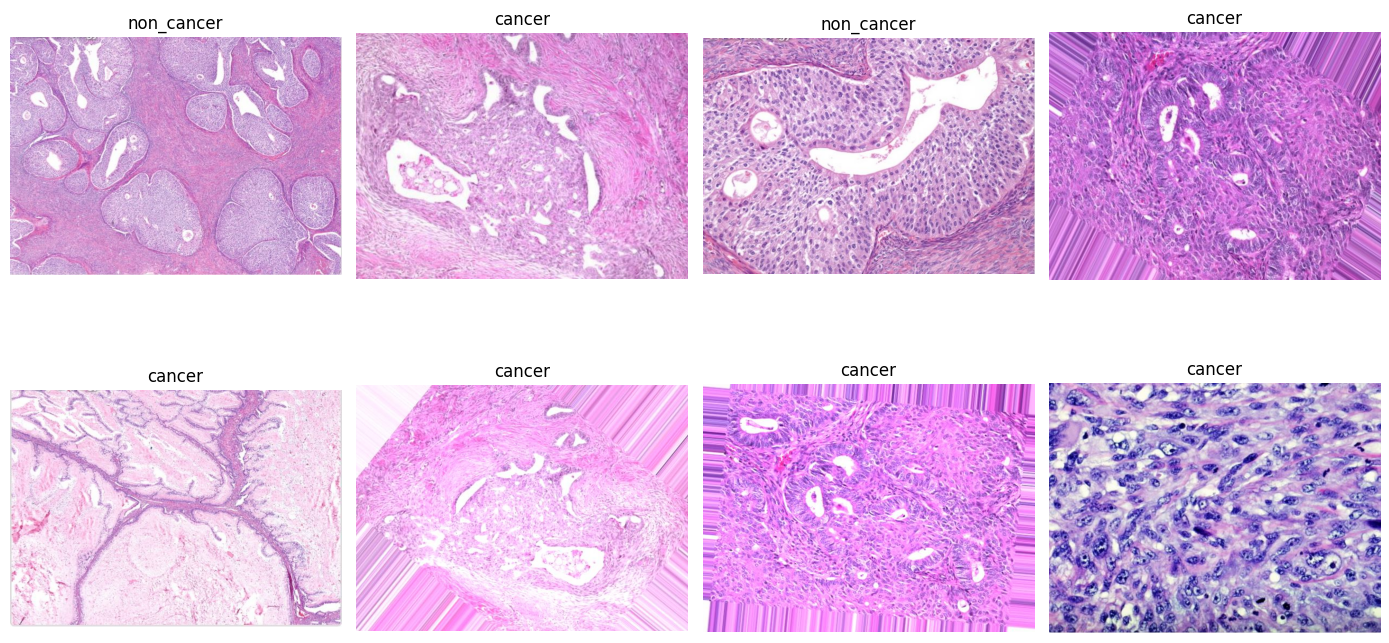

In [14]:
def show_random_images(df: pd.DataFrame, n: int = 8, figsize: Tuple[int, int] = (14, 8)):
    """
    Display random images from the dataframe with their labels.
    """
    sample_df = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    cols = 4
    rows = int(np.ceil(len(sample_df) / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        img = Image.open(row["filepath"]).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["target_name"])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(train_df, n=8)

## Step 5 — Dataset class and transforms

We use:
- standard ImageNet normalization for the ResNet backbone,
- random augmentation for training,
- deterministic resize/crop for validation and test.

The custom dataset below is simple because we already have a dataframe with filepaths and labels.

In [15]:
train_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((cfg.image_size, cfg.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class HistopathologyDataset(Dataset):
    """
    Dataset backed by a dataframe with filepaths and numeric targets.
    """
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        y = int(row["target"])

        if self.transform is not None:
            img = self.transform(img)

        return img, y

train_ds = HistopathologyDataset(train_df, transform=train_transform)
val_ds   = HistopathologyDataset(val_df, transform=eval_transform)
test_ds  = HistopathologyDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=cfg.pin_memory,
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 18
Val batches: 4
Test batches: 4


## Step 6 — Device strategy

We have **two different runtime layers** in this notebook:

1. **Classical PyTorch device** (`cpu` or `cuda`) for the CNN.
2. **Quantum PennyLane device** for the QNN.

We configure them separately.

### Classical device
If CUDA is available, the CNN and classifier head should run on GPU.

### Quantum device
For the QNN we try, in order:
- `lightning.gpu` if requested and available,
- `lightning.qubit`,
- `default.qubit`.

### Gradient method
- `adjoint` is typically the best choice on simulators for speed.
- `parameter-shift` is slower, but useful if you want hardware-style gradients.

In [16]:
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Classical torch device:", torch_device)

def choose_quantum_device(cfg: Config):
    """
    Choose a PennyLane device with safe fallbacks.
    """
    candidates = []
    if cfg.q_device_preference == "auto":
        candidates = ["lightning.gpu", "lightning.qubit", "default.qubit"]
    else:
        candidates = [cfg.q_device_preference, "lightning.qubit", "default.qubit"]

    last_err = None
    for name in candidates:
        try:
            dev = qml.device(name, wires=cfg.n_qubits, shots=cfg.q_shots)
            return name, dev
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Could not initialize any quantum device. Last error: {last_err}")

q_device_name, q_dev = choose_quantum_device(cfg)
print("Quantum device:", q_device_name)
print("Gradient method:", cfg.q_grad_method)
print("Shots:", cfg.q_shots)

Classical torch device: cuda
Quantum device: lightning.gpu
Gradient method: adjoint
Shots: None


## Step 7 — Training and evaluation utilities

We keep the training loop modular so the **same trainer** works for:
- the pure classical baseline,
- the hybrid CNN + QNN model.

We report:
- loss,
- accuracy,
- macro-F1.

Macro-F1 is especially useful when classes are imbalanced.

In [17]:
def run_epoch(model, loader, criterion, optimizer=None, device=torch.device("cpu")):
    """
    Run one training or evaluation epoch.
    """
    is_train = optimizer is not None
    model.train(is_train)

    all_targets = []
    all_preds = []
    running_loss = 0.0

    iterator = tqdm(loader, leave=False)
    for xb, yb in iterator:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)

        all_targets.extend(yb.detach().cpu().numpy().tolist())
        all_preds.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    return {
        "loss": epoch_loss,
        "acc": epoch_acc,
        "f1_macro": epoch_f1,
    }

def train_model(model, train_loader, val_loader, epochs, lr=1e-4, weight_decay=1e-4, device=torch.device("cpu")):
    """
    Train a model and keep the best validation checkpoint in memory.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = []
    best_state = None
    best_val_f1 = -1.0

    for epoch in range(1, epochs + 1):
        train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
        val_metrics = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_acc": train_metrics["acc"],
            "train_f1": train_metrics["f1_macro"],
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["acc"],
            "val_f1": val_metrics["f1_macro"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"train loss={row['train_loss']:.4f}, acc={row['train_acc']:.4f}, f1={row['train_f1']:.4f} | "
            f"val loss={row['val_loss']:.4f}, acc={row['val_acc']:.4f}, f1={row['val_f1']:.4f}"
        )

        if row["val_f1"] > best_val_f1:
            best_val_f1 = row["val_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    hist_df = pd.DataFrame(history)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, hist_df

@torch.no_grad()
def predict_model(model, loader, device=torch.device("cpu")):
    """
    Collect predictions and targets for evaluation.
    """
    model.eval()
    all_targets = []
    all_preds = []

    for xb, yb in tqdm(loader, leave=False):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1)

        all_targets.extend(yb.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    return np.array(all_targets), np.array(all_preds)

def evaluate_and_report(model, loader, class_names, device=torch.device("cpu"), title="Evaluation"):
    """
    Print metrics and plot a confusion matrix.
    """
    y_true, y_pred = predict_model(model, loader, device=device)

    print(title)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Macro-F1:", f1_score(y_true, y_pred, average="macro"))
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(title)
    plt.show()

    return y_true, y_pred

## Step 8 — Classical baseline: ResNet18 transfer learning

Before introducing a quantum layer, we need a strong classical baseline.

Why this matters:
- if the baseline is weak, it is hard to tell whether the QNN helps or hurts,
- transfer learning is usually much stronger than training from scratch on medical images.

We use a pretrained `ResNet18` backbone and replace the final classifier layer.

In [18]:
class BaselineResNet18(nn.Module):
    """
    Purely classical baseline using a pretrained ResNet18.
    """
    def __init__(self, num_classes: int, freeze_backbone: bool = True):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

        if freeze_backbone:
            for name, param in self.backbone.named_parameters():
                param.requires_grad = False
            for param in self.backbone.fc.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

num_classes = len(classes)
baseline_model = BaselineResNet18(num_classes=num_classes, freeze_backbone=cfg.freeze_backbone).to(torch_device)
baseline_model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/vinvs/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 63.9MB/s]


BaselineResNet18(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

### Train the classical baseline

For a first smoke test, keep the number of epochs small.  
Once the pipeline is stable, increase the epochs and remove the per-class cap.

In [19]:
baseline_model, baseline_hist = train_model(
    baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.baseline_epochs,
    lr=1e-4,
    weight_decay=1e-4,
    device=torch_device,
)

baseline_hist

Epoch 01 | train loss=0.6939, acc=0.5607, f1=0.4888 | val loss=0.5590, acc=0.7167, f1=0.4175


Epoch 02 | train loss=0.5984, acc=0.7393, f1=0.4251 | val loss=0.5540, acc=0.7500, f1=0.4286


Epoch 03 | train loss=0.6030, acc=0.7393, f1=0.4251 | val loss=0.5408, acc=0.7500, f1=0.4286


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.693902,0.560714,0.488831,0.558984,0.716667,0.417476
1,2,0.598385,0.739286,0.425051,0.553979,0.750000,0.428571
2,3,0.602966,0.739286,0.425051,0.540776,0.750000,0.428571


Baseline ResNet18 — Test set
Accuracy: 0.7333333333333333
Macro-F1: 0.4230769230769231

              precision    recall  f1-score   support

      cancer     0.7458    0.9778    0.8462        45
  non_cancer     0.0000    0.0000    0.0000        15

    accuracy                         0.7333        60
   macro avg     0.3729    0.4889    0.4231        60
weighted avg     0.5593    0.7333    0.6346        60



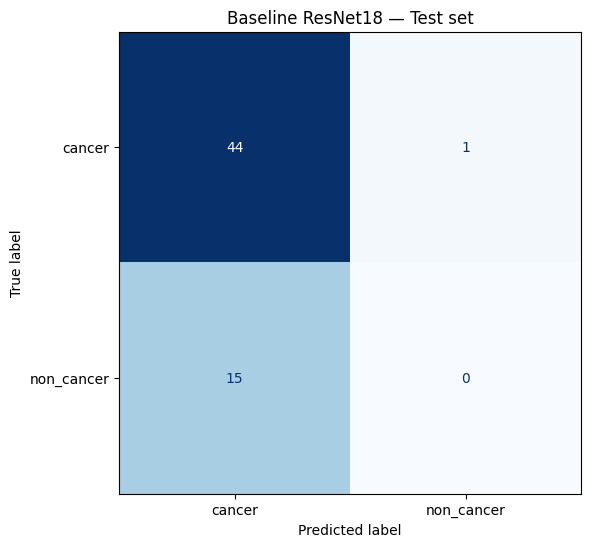

In [20]:
_ = evaluate_and_report(
    baseline_model,
    test_loader,
    class_names=classes,
    device=torch_device,
    title="Baseline ResNet18 — Test set"
)

## Step 9 — Build the QNN block

Now we add the quantum part.

### Design choices
We use:
- `n_qubits` wires,
- **AngleEmbedding** to encode a compact feature vector,
- **data re-uploading**: we embed the same classical features multiple times,
- a trainable entangling block after each re-upload.

### Why data re-uploading?
A small quantum circuit has limited representational power. Re-uploading the input multiple times can increase expressivity without increasing the number of qubits.

### Why return expectation values?
The circuit outputs a small vector of expectation values:
\[
[\langle Z_0 
angle, \ldots, \langle Z_{n-1} 
angle]
\]
which becomes the input to the final classical classifier head.

In [21]:
def make_qnode(cfg: Config, q_dev):
    """
    Create a QNode suitable for wrapping with qml.qnn.TorchLayer.

    Inputs:
    - inputs: shape (n_qubits,)
    - weights: shape (n_reuploads, q_depth_per_block, n_qubits, 3)

    The circuit uses data re-uploading by applying AngleEmbedding
    in each block, followed by trainable entangling layers.
    """
    @qml.qnode(q_dev, interface="torch", diff_method=cfg.q_grad_method)
    def circuit(inputs, weights):
        for b in range(cfg.n_reuploads):
            qml.AngleEmbedding(inputs, wires=range(cfg.n_qubits), rotation="Y")
            qml.StronglyEntanglingLayers(
                weights[b:b+1],
                wires=range(cfg.n_qubits)
            )
        return [qml.expval(qml.PauliZ(i)) for i in range(cfg.n_qubits)]
    return circuit

qnode = make_qnode(cfg, q_dev)
weight_shapes = {
    "weights": (cfg.n_reuploads, cfg.q_depth_per_block, cfg.n_qubits, 3)
}
q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)
q_layer

<Quantum Torch Layer: func=circuit>

## Step 10 — Hybrid CNN + QNN model

Architecture:

**ResNet18 backbone → projector → bounded nonlinear features → QNN → classifier head**

### Why add extra non-linearity?
You specifically asked for newly added non-linearity. We add it in the projector:
- `LayerNorm`
- `GELU`
- `Tanh`

This helps the classical feature vector:
- stay numerically stable,
- be bounded before angle encoding,
- become more expressive before entering the QNN.

In [22]:
class HybridResNetQNN(nn.Module):
    """
    Hybrid image classifier:
    image -> ResNet18 backbone -> projector -> QNN -> classifier head
    """
    def __init__(self, num_classes: int, q_layer: nn.Module, cfg: Config, freeze_backbone: bool = True):
        super().__init__()
        self.cfg = cfg
        self.q_layer = q_layer

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.projector = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, cfg.n_qubits),
            nn.Tanh(),
        )

        self.post_q = nn.Sequential(
            nn.LayerNorm(cfg.n_qubits),
            nn.GELU(),
        )

        self.classifier = nn.Linear(cfg.n_qubits, num_classes)

    def forward(self, x):
        feats = self.backbone(x)
        q_inputs = self.projector(feats)

        # Safe cross-runtime path:
        # keep the CNN on torch_device, send only the small quantum inputs to CPU,
        # run the QNN there, then move the result back.
        q_inputs_cpu = q_inputs.to("cpu")
        q_out = self.q_layer(q_inputs_cpu)
        q_out = q_out.to(x.device)

        q_out = self.post_q(q_out)
        logits = self.classifier(q_out)
        return logits

hybrid_model = HybridResNetQNN(
    num_classes=num_classes,
    q_layer=q_layer,
    cfg=cfg,
    freeze_backbone=cfg.freeze_backbone,
).to(torch_device)

hybrid_model

HybridResNetQNN(
  (q_layer): <Quantum Torch Layer: func=circuit>
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): Batch

### A note about performance

This notebook chooses the **safer** mixed-runtime path:
- CNN on `torch_device` (often GPU),
- QNN input temporarily moved to CPU before the PennyLane layer,
- QNN outputs moved back.

Why? Because this works consistently across many PennyLane simulator setups.

If your environment is fully configured for `lightning.gpu` and your Torch/PennyLane stack accepts that path cleanly, you can later optimize the forward pass to reduce host/device transfers.

For a small QNN (`4–8` qubits), the transfer cost is usually manageable compared to the CNN workload.

## Step 11 — Train the hybrid model

### About gradient choice
- `adjoint`: best default for simulator training speed.
- `parameter-shift`: slower, but a useful experiment when you want a more hardware-style gradient computation.

If you switch to `parameter-shift`, consider:
- reducing `batch_size`,
- reducing `n_reuploads`,
- using fewer epochs at first,
- optionally enabling finite shots.

In [24]:
# Rebuild QNode with correct per-block weight shape usage
def make_qnode(cfg: Config, q_dev):
    @qml.qnode(q_dev, interface="torch", diff_method=cfg.q_grad_method)
    def circuit(inputs, weights):
        for b in range(cfg.n_reuploads):
            qml.AngleEmbedding(inputs, wires=range(cfg.n_qubits), rotation="Y")
            # IMPORTANT: use weights[b], not weights[b:b+1]
            qml.StronglyEntanglingLayers(weights[b], wires=range(cfg.n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(cfg.n_qubits)]

    return circuit


qnode = make_qnode(cfg, q_dev)
weight_shapes = {"weights": (cfg.n_reuploads, cfg.q_depth_per_block, cfg.n_qubits, 3)}
q_layer = qml.qnn.TorchLayer(qnode, weight_shapes)

hybrid_model = HybridResNetQNN(
    num_classes=num_classes,
    q_layer=q_layer,
    cfg=cfg,
    freeze_backbone=cfg.freeze_backbone,
).to(torch_device)

hybrid_model, hybrid_hist = train_model(
    hybrid_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.hybrid_epochs,
    lr=1e-4,
    weight_decay=1e-4,
    device=torch_device,
)

hybrid_hist

Epoch 01 | train loss=0.6725, acc=0.6964, f1=0.5018 | val loss=0.6521, acc=0.7500, f1=0.4286


Epoch 02 | train loss=0.6488, acc=0.7500, f1=0.4286 | val loss=0.6477, acc=0.7500, f1=0.4286


Epoch 03 | train loss=0.6459, acc=0.7500, f1=0.4286 | val loss=0.6450, acc=0.7500, f1=0.4286


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.672488,0.696429,0.501832,0.652056,0.75,0.428571
1,2,0.648832,0.750000,0.428571,0.647688,0.75,0.428571
2,3,0.645919,0.750000,0.428571,0.644987,0.75,0.428571


Hybrid ResNet18 + QNN — Test set
Accuracy: 0.75
Macro-F1: 0.42857142857142855

              precision    recall  f1-score   support

      cancer     0.7500    1.0000    0.8571        45
  non_cancer     0.0000    0.0000    0.0000        15

    accuracy                         0.7500        60
   macro avg     0.3750    0.5000    0.4286        60
weighted avg     0.5625    0.7500    0.6429        60



/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vinvs/projects/quantum/bio-quantum/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

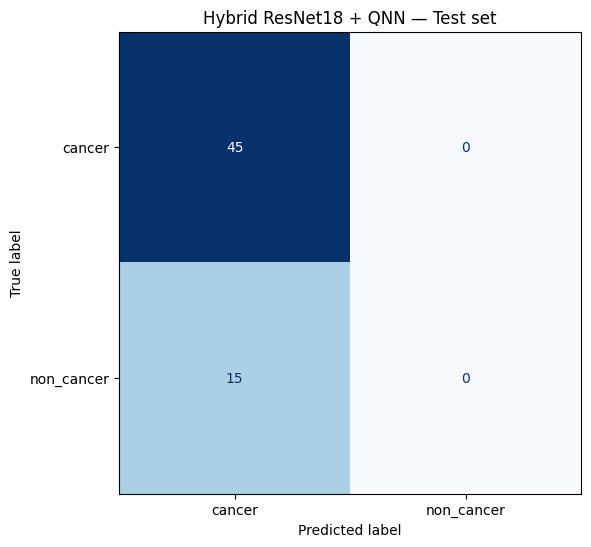

In [25]:
_ = evaluate_and_report(
    hybrid_model,
    test_loader,
    class_names=classes,
    device=torch_device,
    title="Hybrid ResNet18 + QNN — Test set"
)

## Step 12 — Compare the learning curves

A direct visual comparison helps answer:

- Is the hybrid model underfitting?
- Is it slower to stabilize?
- Does it improve validation macro-F1?

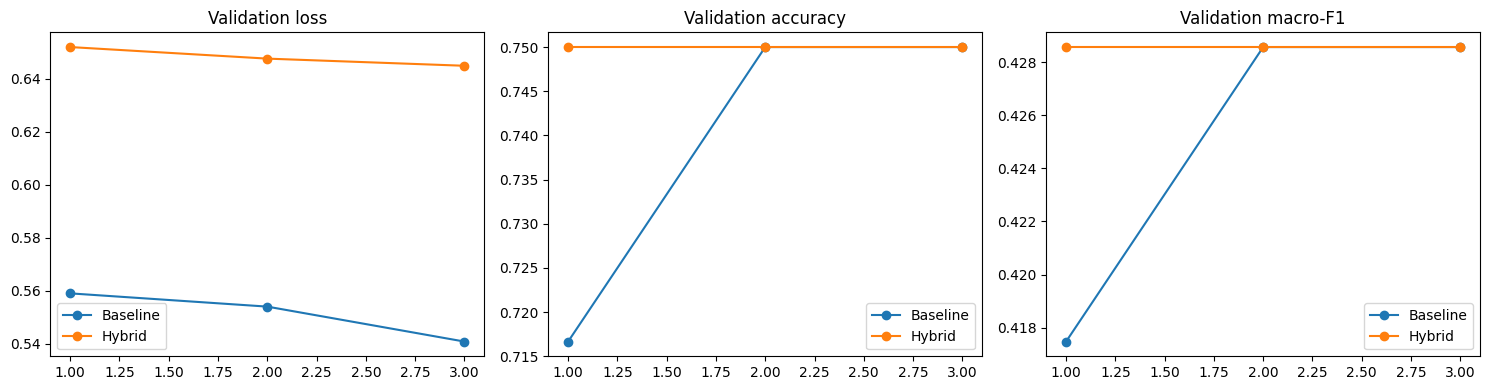

In [26]:
def plot_histories(hist_a: pd.DataFrame, hist_b: pd.DataFrame, label_a="Baseline", label_b="Hybrid"):
    """
    Plot validation metrics for two training histories.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(hist_a["epoch"], hist_a["val_loss"], marker="o", label=label_a)
    axes[0].plot(hist_b["epoch"], hist_b["val_loss"], marker="o", label=label_b)
    axes[0].set_title("Validation loss")
    axes[0].legend()

    axes[1].plot(hist_a["epoch"], hist_a["val_acc"], marker="o", label=label_a)
    axes[1].plot(hist_b["epoch"], hist_b["val_acc"], marker="o", label=label_b)
    axes[1].set_title("Validation accuracy")
    axes[1].legend()

    axes[2].plot(hist_a["epoch"], hist_a["val_f1"], marker="o", label=label_a)
    axes[2].plot(hist_b["epoch"], hist_b["val_f1"], marker="o", label=label_b)
    axes[2].set_title("Validation macro-F1")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

plot_histories(baseline_hist, hybrid_hist)

## Step 13 — Suggested experiments

Once the basic notebook works end-to-end, run the following ablations.

### A) Binary vs multiclass
- `cfg.task_mode = "binary"`
- `cfg.task_mode = "multiclass"`

### B) Data re-uploading depth
- `cfg.n_reuploads = 1`
- `cfg.n_reuploads = 3`
- `cfg.n_reuploads = 5`

Hypothesis:
- more re-uploading can increase expressivity,
- but also increases optimization cost.

### C) Number of qubits
- `cfg.n_qubits = 4`
- `cfg.n_qubits = 6`
- `cfg.n_qubits = 8`

Keep in mind:
- simulation cost grows quickly,
- the best result is not always the one with the most qubits.

### D) Gradient method
- `cfg.q_grad_method = "adjoint"`
- `cfg.q_grad_method = "parameter-shift"`

Expected tradeoff:
- `adjoint` should train faster on simulators,
- `parameter-shift` gives you a more hardware-relevant experiment.

### E) Freeze vs unfreeze backbone
- first train with the backbone frozen,
- then unfreeze the last ResNet block for fine-tuning.

This is a good way to test whether the QNN helps once the classical features become task-specific.

## Step 14 — Optional: switch to parameter-shift

The cell below shows the minimal config changes you can make to run the same model with parameter-shift.

This will usually be **much slower** than adjoint on a simulator, so it is best treated as an ablation, not the default.

In [ ]:
# Example config edits for a parameter-shift experiment:
#
# cfg.q_grad_method = "parameter-shift"
# cfg.q_shots = 256
# cfg.batch_size = 8
# cfg.n_reuploads = 2
# cfg.hybrid_epochs = 2
#
# q_device_name, q_dev = choose_quantum_device(cfg)
# qnode = make_qnode(cfg, q_dev)
# q_layer = qml.qnn.TorchLayer(
#     qnode,
#     {"weights": (cfg.n_reuploads, cfg.q_depth_per_block, cfg.n_qubits, 3)}
# )
# hybrid_model = HybridResNetQNN(
#     num_classes=len(classes),
#     q_layer=q_layer,
#     cfg=cfg,
#     freeze_backbone=cfg.freeze_backbone,
# ).to(torch_device)
#
# hybrid_model, hybrid_hist = train_model(
#     hybrid_model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     epochs=cfg.hybrid_epochs,
#     lr=1e-4,
#     weight_decay=1e-4,
#     device=torch_device,
# )

## Step 15 — Practical conclusions

### What is the recommended starting point?
For this dataset and this hybrid setup, the most practical first experiment is:

- **binary classification**
- **ResNet18 baseline**
- **4 qubits**
- **3 data re-uploads**
- **adjoint differentiation**
- backbone frozen initially
- capped dataset size for quick debugging

### Why this setup?
It gives you:
- a strong classical reference,
- a realistic hybrid quantum architecture,
- manageable simulator cost,
- a clean path for ablation studies.

### What should you report in a class project?
At minimum:
1. dataset/task definition,
2. baseline architecture,
3. hybrid architecture,
4. quantum circuit design,
5. effect of data re-uploading,
6. adjoint vs parameter-shift comparison,
7. train/val/test metrics,
8. confusion matrix and error analysis.

## References used to motivate the notebook design

- PennyLane `qml.qnn.TorchLayer`
- PennyLane PyTorch interface
- PennyLane parameter-shift rule
- Data re-uploading for a universal quantum classifier
- Kaggle ovarian cancer histopathology dataset page
- Torchvision ResNet18 docs

The notebook itself is self-contained, but these references explain why the design choices above are reasonable.